<a href="https://colab.research.google.com/github/RyuZULi/Python_AI/blob/master/260706.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. latex math: 數學式子表示器
1. $ \sigma = \sqrt { \frac{1}{n} \sum_{1-n} { (x_i -\mu) ^2} }$

#### 1. 統計重點
Y 輸出 X輸入
#### 2. 輸出
1. 分類問題(Classfication): 輸出是選擇題
2. 數值問題(Regression): 輸出是計算問題
3. 分群問題(Cluster): 沒有輸出(把輸出和方程式都建立起來)(深度學習沒有)
4. 強化學習

#### 3. Python 常用函式庫
1. scikit-learn: 最常用，別名 sklearn
2. numpy: 很少直接用，矩陣運算
3. scipy: 比較少用到，你的統計量是比較少用，e.g. skewness/box-cox轉換
4. pandas: 超級常用，處理表格
5. matplotlib: 畫圖基礎
6. seaborn: 進階畫圖函式庫

In [70]:
# Step1把你的資料整理成表格
# 並先存成一份CSV(comma-searated values)
# 用透號分隔每一格，用換行分隔每一筆
import pandas as pd
from sklearn.datasets import load_iris

data = load_iris()
# pandas: DataFrame(表格)、Series(一行、一列)
#橫:row/列、直:columns/行
df = pd.DataFrame(data["data"],
             columns =data["feature_names"])
df["target"] = data["target"]
df.to_csv("iris.csv",encoding = "utf-8", index = False)
# index 列標籤
# index = True read_csv (index_col = 0)
# index = Fales read_csv()

In [71]:
# step2 . 評估一下你的資料量夠不夠
# 機器學習: 千筆以上(萬筆比較好)
# 深度學習: 萬筆以上
# 問題複雜度: 複雜度(有效輸入越多)越高，越多資料 => 維度問題

# step3 分兩部分
# 1.訓練資料(給模型訓練)
# 2.驗證資料(驗證模型資料)

from sklearn.model_selection import train_test_split
train_test_split([1,2,3,4],
                 [5,6,7,8],
                 [34,65,54,87],
                 test_size= 0.25)


# x,y分出來
# drop(): pandas只要看到axis 只有0,1兩種，方向相反
# demo = pd.DataFrame([
#     [1,2],
#     [6,8]
# ], columns=["a","b"],index=["1","2"])

x = df.drop("target",axis=1)
y = df["target"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25)

In [72]:
#step 4 建立模型
from sklearn.tree import DecisionTreeClassifier

# 過擬合: 任何模型都要防止，防止過度學習資料
# 因為過度學習資料，通常反而會在現實資料表現得很差
# 調參數大部分時候就是為了控制擬合度
clf = DecisionTreeClassifier(max_depth=3)
# fit是訓練的意思
clf.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

[Text(0.375, 0.875, 'petal length (cm) <= 2.5\ngini = 0.667\nsamples = 112\nvalue = [38, 37, 37]\nclass = setosa'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 38\nvalue = [38, 0, 0]\nclass = setosa'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'petal length (cm) <= 4.75\ngini = 0.5\nsamples = 74\nvalue = [0, 37, 37]\nclass = versicolor'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'sepal length (cm) <= 4.95\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]\nclass = versicolor'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]\nclass = versicolor'),
 Text(0.75, 0.375, 'petal width (cm) <= 1.75\ngini = 0.18\nsamples = 40\nvalue = [0, 4, 36]\nclass = virginica'),
 Text(0.625, 0.125, 'gini = 0.5\nsamples = 6\nvalue = [0, 3, 3]\nclass = versicolor'),
 Text(0.875, 0.125, 'gini = 0.057\nsamples = 34\nvalue = [0, 1, 33]\nclass = virginica')]

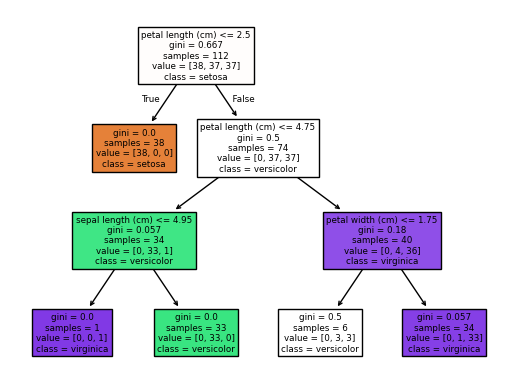

In [73]:
from sklearn.tree import plot_tree
plot_tree(clf,
          feature_names= x.columns,
          filled=True,
          class_names=data["target_names"])

In [74]:
# step 5 用測試資料確認參數
# metrics 評估的工具
from sklearn.metrics import accuracy_score
pre = clf.predict(x_test)
accuracy_score(y_test, pre)

0.9473684210526315

In [75]:
# 分類metrics: 如果只用accurary score 會在imblanced datasets有問題
# 不平衡的話，你乾脆不用分
# accuracy: 一般情況都好
# precision/recall: f1: imbalance好用
# precision(精確率) = 真的是/你說是的 => 嚴謹，寧可放過，不錯殺
# Recall(召回率) = 你找到多少為是/母體為是 => 寧可錯殺，不放過
# Precision 和 Recall 是trade-off
# f1(平均值): precision & recall 的調和平均 => 2*PR*RE / PR+RE
# f1 = 0.6-0.7就不錯了

# 一次平均: ( |差值| + |差值| + ... )/ 項目數量
# 二次平均: ( [(差值)^2 + (差值)^2 + ... ) / 項目數量] ^0.5  => 會被較大值拉走

# 負一次平均(調和平均):   ( [(差值)^-1 + (差值)^-1 + ... ) / 項目數量] ^-1  =>會被較小值拉走
from sklearn.metrics import classification_report
print(classification_report(y_test,pre))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.92      0.92      0.92        13
           2       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38

